#### Midterm 2
- Chris O

In [1]:
# general libraries
import cvxpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# libraries for question 1
from scipy.differentiate import hessian

# libraries for Question 3
import json # import api key
import requests # obtain stock price data from financial data API (free)
from datetime import datetime, date
from tqdm import tqdm



#### Question 1 [ Steepest Descent Algorithm ]
- Reference: Section 9.2-9.4 [Gradient Descent, Convergence, and Line Search/Backtracking]

In [19]:
x0 = np.array([1, 1, 1]).reshape(-1,1)
print(f"{x0}")
t = 0.01 # step size
eps = 1e-6

[[1]
 [1]
 [1]]


In [20]:
def f(x):
    return (x[0] + 5)**2 + (x[1] + 8)**2 + (x[2] + 7)**2 + 2*x[0]**2*x[1]**2 + 4*x[0]**2*x[2]**2

Steepest Descent Algorithm

1. Compute the steepest descent direction: compute the gradient (vector of partial first-order derivatives)
2. Evaluate the gradient at x0
3. Update the value x1 = x0 + t * gradient_x

   Store values of f(x) at each iteration.
   Store values of x at each iteration.
   Output x*.

In [21]:
def gradf(x):
    x1, x2, x3 = x[0:3]
    return np.array([[2*(x1+5) + 4*x2**2*x1 + 8*x3**2*x1],
                    [2*(x2+8) + 4*x1**2*x2],
                    [2*(x3+7) + 8*x1**2*x3]]).reshape(-1,1)

In [22]:
x_vec = [] # store xk at each iteration k
fx_vec = [] # store function values f(xk) at each iteration k 

In [23]:
from tqdm import tqdm

```
max_iter = 90
xcur = x0
iter_nums = []

for k in tqdm(range(1, max_iter+1)): #i.e., 1,...,k
    # compute the gradient at x
    gradient = gradf(xcur)
    
    x_vec.append(xcur)
    iter_nums.append(k)
    
    # Update the value x1 = x0 + t * gradient_x
    xnew = xcur - t * gradient

    #Store values of f(x) at each iteration. Store values of x at each iteration. Output x*.
    f_xcur = f(xcur)
    f_xnew = f(xnew)

    fx_vec.append(f_xcur[0])
    
    if np.abs(f_xcur - f_xnew) < eps:
        break

    xcur = xnew
    #if k == max_iter:
    #    print("no solution found")

In [43]:
x0 = np.array([1, 1, 1]).reshape(-1,1)
print(f"{x0}")
t = 0.01 # step size
eps = 1e-6
max_iter = 100

solution_vec = [] # store x values per iteration
fx_vec = [] # store function values per iteration
iter_nums = []

# initialize weight and intercept
x = x0
fx = f(x0)

alpha = 0.01 # step size

i = 1 # keep track of iteration number

solution_vec.append(x) # store existing value of x
cur_fx = fx
fx_vec.append(cur_fx[0]) # store existing function value 
iter_nums.append(i)

while i <= max_iter: # stop if reached max iterations

    # compute the gradients at x
    x_grads = gradf(x)

    #print(f"gradients = {x_grads}, f(x) = {cur_fx}, i = {i}")
    
    # update the weights 
    x[0] = x[0] - t * x_grads[0]
    x[1] = x[1] - t * x_grads[1]
    x[2] = x[2] - t * x_grads[2]
    
    # compute the new MSE (obj. function value)
    new_fx = f(x)

    if np.abs(cur_fx - new_fx) < eps:
        break

    solution_vec.append(x) # store new value of x 
    fx_vec.append(new_fx[0]) # store new function value 

    # prepare for next iteration
    i += 1 # increment to next iteration
    cur_fx = new_fx
    iter_nums.append(i) # store iteration number

[[1]
 [1]
 [1]]


In [44]:
solution_vec

[array([[0],
        [0],
        [0]]),
 array([[0],
        [0],
        [0]])]

##### a) Verify that x* satisfies the second order necessary condition for a minimim
- compute the Hessian matrix i.e., matrix of partial derivatives

    - (scipy.hessian](https://docs.scipy.org/doc/scipy/reference/generated/scipy.differentiate.hessian.html)

- show that the Hessian is positive definite plugging in x* i.e., Hj > 0

    - compute the determinants of the Hessian Matrix evaluated at x* numpy.linalg.det

In [45]:
hessian(f, solution_vec[-1])

     success: [[[ True]
                [False]
                [False]]
              
               [[False]
                [ True]
                [False]]
              
               [[False]
                [False]
                [ True]]]
      status: [[[ 0]
                [-1]
                [-1]]
              
               [[-1]
                [ 0]
                [-2]]
              
               [[-1]
                [-1]
                [ 0]]]
       error: [[[ 1.968e-12]
                [ 2.622e-11]
                [ 1.496e-10]]
              
               [[ 2.753e-09]
                [ 2.448e-12]
                [ 1.264e-10]]
              
               [[ 3.915e-10]
                [ 1.260e-10]
                [ 2.409e-12]]]
        nfev: [[[121]
                [165]
                [209]]
              
               [[297]
                [121]
                [297]]
              
               [[231]
                [209]
                [121]]]


In [46]:
# compute the determinants of the Hessian matrix
hessian(f, solution_vec[-1]).ddf

array([[[ 2.00000000e+00],
        [ 2.98712166e-11],
        [ 1.03455022e-10]],

       [[-2.69756129e-09],
        [ 2.00000000e+00],
        [ 1.45519152e-11]],

       [[ 3.49700713e-10],
        [ 1.25965016e-10],
        [ 2.00000000e+00]]])

##### b) Plot the value of the objective function with respect to the number of iterations

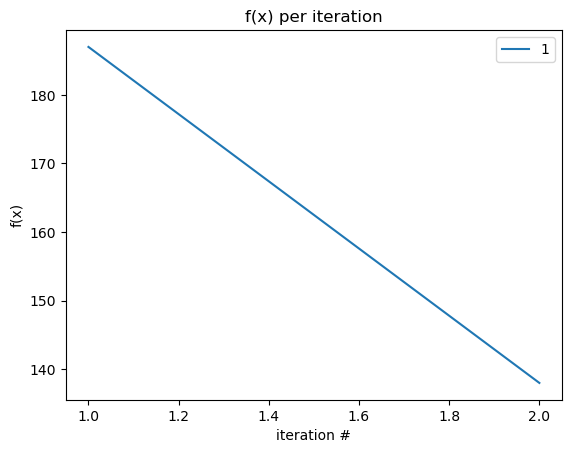

In [47]:
pd.DataFrame(zip(iter_nums, fx_vec)).set_index(0).plot()
plt.xlabel('iteration #'); plt.ylabel(f"f(x)")
plt.title(f"f(x) per iteration")
plt.show()

##### c) Comment on the convergence speed of the algorithm.

#### Question 2
- Reference: Section 11.3 [Barrier Method] - Page 568
- 

In [112]:
def f(x):
    x1 = x[0]
    x2 = x[1]
    return (x1 - 1)**2 + 2*(x2 - 2)**2
def cons1(x):
    x1 = x[0]
    x2 = x[1]
    return x1**2 + x2**2 -1 # <= 0
def cons2(x):
    x1 = x[0]
    x2 = x[1]
    return -x1 - x2 # <= 0
def fmodified(x, r):
    x1 = x[0]
    x2 = x[1]
    r1 = r[0]
    r2 = r[1]
    return f(x) + r1 * np.log(-x1**2 - x2**2 + 1) + r2 * np.log(x1 + x2)
def fmodifiedgradient(x, r):
    x1 = x[0]
    x2 = x[1]
    r1 = r[0]
    r2 = r[1]
    return np.array([
                    2*(x1 - 1) - r1 * (1/(-x1**2 - x2**2 +1))*(-2*x1) - r2 * (1/(x1+x2)), 
                    2*(x2 - 2) - r1 * (1/(-x1**2 - x2**2 +1))*(-2*x2) - r2 * (1/(x1+x2))
                    ])

##### (a) Plot the contour of f(¯x) and the feasible set on one single figure, i.e., overlay the feasible set on the contour plot of f(¯x)
- [matplotlib.pyplot.contour](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contour.html)

```x1 = np.arange(0, 50, 10)
x2 = x1.reshape(-1,1)
#x2 = np.linspace(-5, 5, 50)
func = f(x1, x2)
constraint1 =  cons1(x1, x2)
constraint2 =  cons2(x1, x2)
#x2 = np.linspace(-1,1, 50)

```
plt.plot(x1, func)
#plt.plot(x1, constraint1)
#plt.plot(x1, constraint2)
plt.show()

In [106]:
x1 = np.arange(-5, 5,  1)
x2 = x1.reshape(-1,1)
x, y = np.meshgrid(x1, x2)

z = (x - 1)**2 + 2*(y - 2)**2
c1 = x**2 + y**2 -1 # <= 0
c2 = -x - y # <= 0

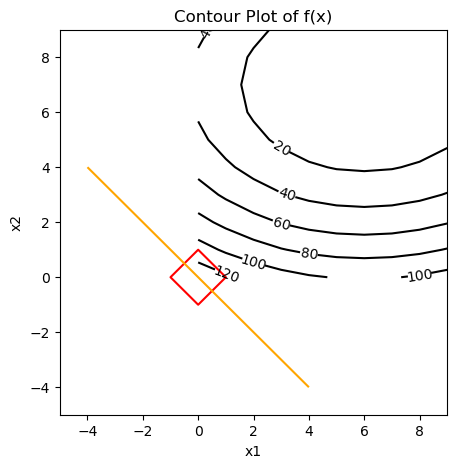

In [107]:
# Reference: https://matplotlib.org/stable/gallery/images_contours_and_fields/contours_in_optimization_demo.html 
fig, ax = plt.subplots(figsize=(5,5))

#z = f(x, y)
#c1 = cons1(x, y)
#c2 = cons2(x, y)

obj = ax.contour(z, colors='black')
ax.clabel(obj, fmt="%2.0f", use_clabeltext=True)

ax.contour(x, y, c1, [0], colors='red')
ax.contour(x, y, c2, [0], colors='orange')
plt.title('Contour Plot of f(x)'); plt.xlabel('x1'); plt.ylabel('x2');
plt.show()

In [114]:
r0 = np.array([1, 1]).reshape(-1,1)
x0 = np.array([0.5, 0.5]).reshape(-1,1)
print(f"{r0}")
t = 0.5 # step size
eps = 0.002
max_iter = 5

solution_vec = [] # store x values per iteration
penalty_vec = [] # store r values per iteration
fx_vec = [] # store function values per iteration
iter_nums = []

# initialize barrier weights, initial guess (x), and initial function value 
r = r0
x = x0
fx = fmodified(x, r)

i = 1 # keep track of iteration number

solution_vec.append(x) # store existing value of x
penalty_vec.append(r) # store existing value of r
cur_fx = fx
fx_vec.append(cur_fx[0]) # store existing function value 
iter_nums.append(i)

while i <= max_iter: # stop if reached max iterations

    # compute the gradients at x
    x_grads = fmodifiedgradient(x, r)

    # update the x values
    x[0] = x[0] - t * x_grads[0]
    x[1] = x[1] - t * x_grads[1]

    # update the barrier penalties
    r[0] = r[0] * t
    r[1] = r[1] * t
    
    # compute the new MSE (obj. function value)
    new_fx = fmodified(x, r)

    if np.abs(cur_fx - new_fx) < eps:
        break

    solution_vec.append(x) # store new value of x 
    penalty_vec.append(r) # store new value of r
    fx_vec.append(new_fx[0]) # store new function value 

    # prepare for next iteration
    i += 1 # increment to next iteration
    cur_fx = new_fx
    iter_nums.append(i) # store iteration number

[[1]
 [1]]


C:\Users\chris\AppData\Local\Temp\ipykernel_30280\1156864434.py:18: RuntimeWarning: invalid value encountered in log
  return f(x) + r1 * np.log(-x1**2 - x2**2 + 1) + r2 * np.log(x1 + x2)


In [117]:
solution_vec

[array([[1.],
        [2.]]),
 array([[1.],
        [2.]]),
 array([[1.],
        [2.]]),
 array([[1.],
        [2.]]),
 array([[1.],
        [2.]]),
 array([[1.],
        [2.]])]

In [118]:
penalty_vec

[array([[0],
        [0]]),
 array([[0],
        [0]]),
 array([[0],
        [0]]),
 array([[0],
        [0]]),
 array([[0],
        [0]]),
 array([[0],
        [0]])]

(b) Find a solution to the problem using the natural logarithmic barrier function, i.e., the barrier function is $-\log{h_1(\bar{x}}) − \log{h_2(\bar{x})}$. Use initialization vector $[0.5, 0.5]^T$ and the initial penalty parameter equal to 1 and reduce it by $\frac{1}{2}$ in each iteration. Use a stopping threshold of 0.002

##### (c) In a 2-D figure, plot the trajectory (i.e., the values connected by lines with arrows) of the computed solution vector as the number of iteration progresses.
- matplotlib.pyplot.quiver https://www.statology.org/matplotlib-quiver/

#### Question 3: Collect the stock price for NVDIA (NASDAQ: NVDA) for the past 30 days.

##### (a) Plot the data (date vs. stock price)
- [FinancialData API](https://financialdata.net/documentation)

Python Resources: 
- [1.5. Stochastic Gradient Descent](https://scikit-learn.org/stable/modules/sgd.html)
- [SGDRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html#sklearn.linear_model.SGDRegressor)
- [sklearn.pipeline](https://scikit-learn.org/stable/modules/preprocessing.html)

In [16]:
with open('api_keys.json', 'r') as f:
    api_key = json.load(f)['api_key']

In [2]:
# define inputs
ticker = 'NVDA'
end_date = datetime.today().date()
start_date = end_date - pd.Timedelta(days=30)

In [3]:
print(f"Retrieve stock data for {ticker} for timeframe {start_date} to {end_date}")

Retrieve stock data for NVDA for timeframe 2026-03-20 to 2026-04-19


In [54]:
query = f"https://financialdata.net/api/v1/stock-prices?identifier={ticker}&date>={start_date}&date<={end_date}&key={api_key}"
print(query)
response = requests.get(query)
response

In [58]:
data = pd.DataFrame(response.json())
data.to_csv(f"{ticker}_data.csv", index=False)
response.close()

In [4]:
# read in data
data = pd.read_csv(f"{ticker}_data.csv", parse_dates=['date'])
data = data.set_index('date')
data = data.sort_index(ascending=True)
data.index = data.index.date
data = data.loc[start_date : end_date] # 20 days (i.e., trading days), go back further to get 30 days

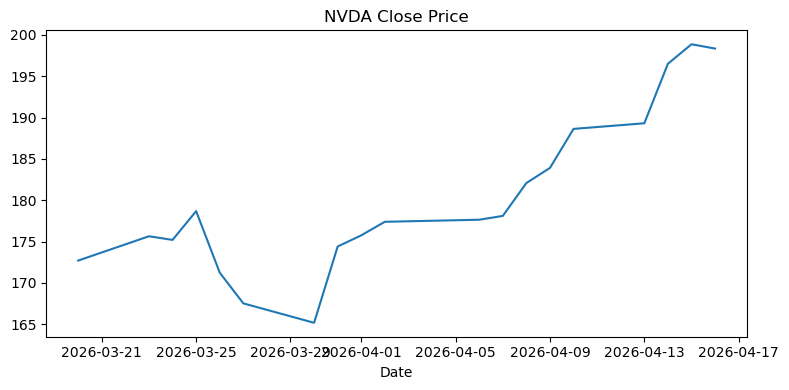

In [5]:
plt.figure(figsize=(8,4))
data['close'].plot()
plt.title(f"{ticker} Close Price")
plt.xlabel('Date');
plt.tight_layout()
plt.show()

##### (b) Implement the stochastic gradient descent algorithm to fit a linear regression model for this data set. Use any required open source libraries. Note that this specific algorithm was not discussed in the class, but all the key ingredients have been covered. So, you must be able to understand how this works.
- from sklearn.linear_model import SGDClassifier
- https://scikit-learn.org/stable/modules/sgd.html

```
from sklearn.linear_model import SGDRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [6]:
# MSE cost function
def MSE(y, x, w0, b0):
    return (y - w0*x - b0)**2

In [7]:
# computes the gradients of the MSE cost function with respect to w and b
def gradientMSE(x, y, w0, b0):
    w = -2 * x * (y - w0*x - b0)
    b = -2 * (y * w0*x - b0)
    return w, b

In [8]:
x0 = np.array([1, 1]).reshape(-1,1)
max_iter = 100
eps = 1e-4 # convergence tolerance
w_vec = [] # store w (weights) per iteration
b_vec = [] # store b (intercept) per iteration
mse_vec = [] # store MSE cost per iteration
iter_nums = []

# initialize weight and intercept
w = x0[0]
b = x0[1]

alpha = 0.01 # step size

i = 1 # keep track of iteration number
j = 1 # keep track of data observation used for gradient 

w_vec.append(w[0]) # store existing value of w 
b_vec.append(b[0]) # store existing value of b 
sgd_obs = data['close'].iloc[j-1] # set jth obs
cur_mse = MSE(sgd_obs, j, w, b) # compute current mse
mse_vec.append(cur_mse[0]) # store existing MSE value 
iter_nums.append(i)

while i <= max_iter: # stop if reached max iterations

    # compute the gradients at x
    w_grad, b_grad = gradientMSE(j, sgd_obs, w, b)

    #print(f"w = {w}, b = {b}, MSE = {cur_mse}, w_grad = {w_grad}, b_grad = {b_grad}, i = {i}")

    # update the weights 
    w = w - alpha * w_grad
    b = b - alpha * b_grad

    # compute the new MSE (obj. function value)
    new_mse = MSE(sgd_obs, j, w, b)

    if np.abs(cur_mse - new_mse) < eps:
        break

    w_vec.append(w[0]) # store new value of w 
    b_vec.append(b[0]) # store new value of b 
    mse_vec.append(new_mse[0]) # store new MSE value 

    # prepare for next iteration
    i += 1 # increment to next iteration
    j += 1 # increment to next observation 
    if j > data['close'].shape[0]: #i.e., j == n (last obs), restart from first observation again j = 1
        j = 1
    sgd_obs = data['close'].iloc[j-1] # set jth+1 obs
    cur_mse = new_mse    
    iter_nums.append(i) # store iteration number


In [9]:
results_df = pd.DataFrame({'w' : pd.Series(w_vec), 
              'b' : pd.Series(b_vec), 
              'mse' : pd.Series(mse_vec), 
              'iter_num' : pd.Series(iter_nums)})#.set_index('iter_num')

In [10]:
results_df['y_pred'] = results_df.apply(lambda row: row['w'] * row['iter_num'] + row['b'], axis=1)

In [11]:
def f(x, w, b):
    return w*x + b

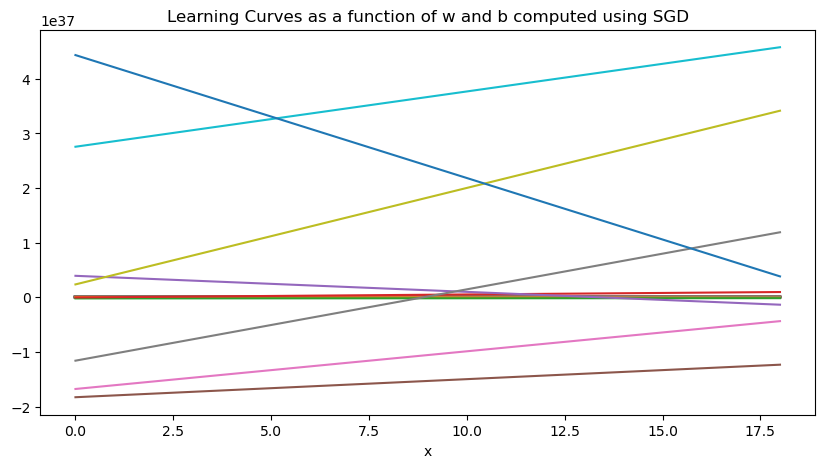

In [12]:
#x = np.linspace(0, 1, 100)
x = np.array([i[0] for i in enumerate(data['close'].index)])
plt.figure(figsize=(10,5))
for i in results_df.index:
    w = results_df.loc[i, 'w']
    b = results_df.loc[i, 'b']
    y_vec = f(x, w, b)
    plt.plot(x, y_vec, label=f"y = {w}*x + {b}")
#plt.legend()
plt.title("Learning Curves as a function of w and b computed using SGD")
plt.xlabel('x')
plt.show()

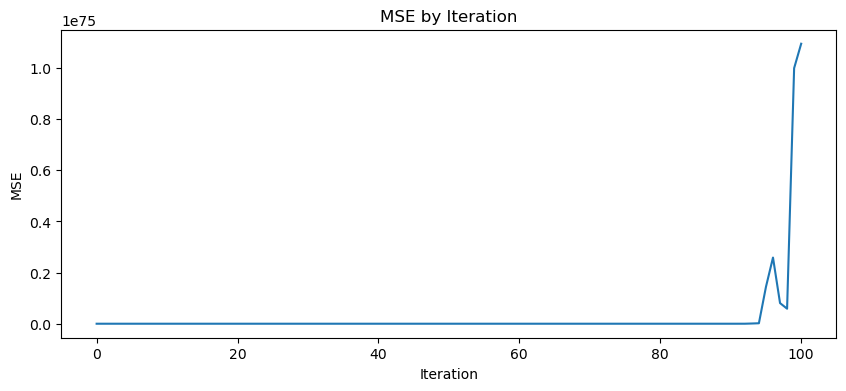

In [13]:
# plot MSE curves against iteration number 
plt.figure(figsize=(10,4))
plt.plot(results_df['mse'])
#plt.xticks(results_df['iter_num'])
plt.title("MSE by Iteration")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.show()

In [15]:
# select the line of best fit with the lowest MSE
opt_iter_num = results_df.idxmin()['mse']
opt_iter = results_df.loc[opt_iter_num]
opt_iter

w            17.336099
b           149.325861
mse         682.994285
iter_num      4.000000
y_pred      218.670259
Name: 3, dtype: float64

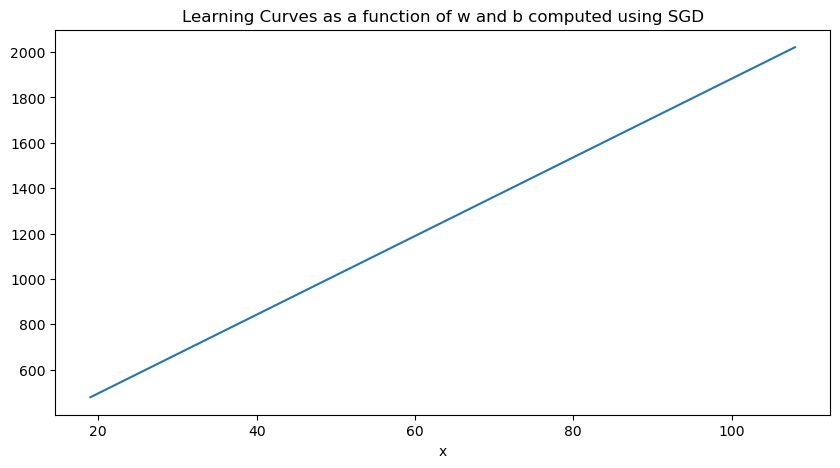

In [16]:
# predict prices for 3 months forward period (using optimal best fit line)
x = np.arange(data['close'].index.shape[0], data['close'].index.shape[0]+90)
plt.figure(figsize=(10,5))
w = results_df.loc[opt_iter_num, 'w']
b = results_df.loc[opt_iter_num, 'b']
y_vec = f(x, w, b)
plt.plot(x, y_vec, label=f"y = {w}*x + {b}")
#plt.legend()
plt.title("Learning Curves as a function of w and b computed using SGD")
plt.xlabel('x')
plt.show()

In [17]:
final_series = data['close'].reset_index()
future_series = pd.concat([
    pd.Series(pd.bdate_range(data['close'].index.max(), data['close'].index.max()+pd.Timedelta(days=125))),
    pd.Series(y_vec)
], axis=1)
future_series = future_series.rename(columns={0 : 'index', 1 : 'close'})
final_series = pd.concat([final_series, future_series], ignore_index=True, axis=0)

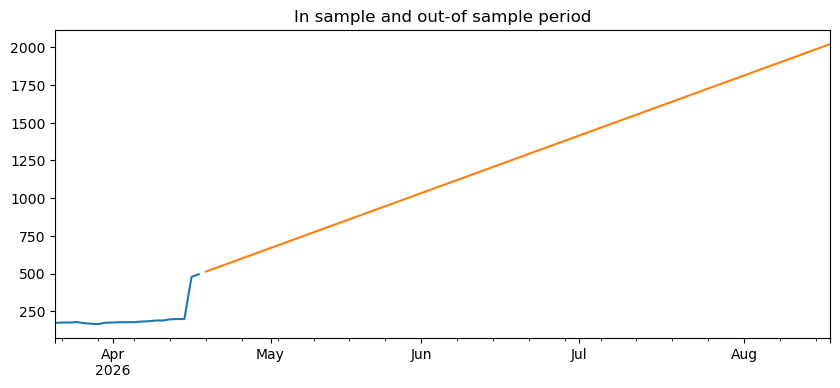

In [18]:
x = pd.bdate_range(data['close'].index.min(), data['close'].index.max()+pd.Timedelta(days=125))
final_series.set_index(x).loc[start_date : end_date]['close'].plot(figsize=(10,4))
final_series.set_index(x).loc[end_date : ]['close'].plot()
plt.title('In sample and out-of sample period')
plt.show()

```
# define hyperparameters
sdg_params = {'max_iter' : 1000, 'loss' : 'squared_error'}
sdg_reg = SGDRegressor(**sdg_params)
pipe = make_pipeline(StandardScaler(), sdg_reg)
```

```
pipe.fit(data[data.columns[~data.columns.isin(['close', 'trading_symbol'])]], data['close'])

```
#y_preds = sdg_reg.predict(data[data.columns[~data.columns.isin(['close', 'trading_symbol'])]])
y_preds = pipe.predict(data[data.columns[~data.columns.isin(['close', 'trading_symbol'])]])

```
data['y_preds'] = y_preds

##### (c) Plot the raw data and your linear regression model together for visual comparison.
- Show learning curves as SGD approaches the line of best fit

```
plt.figure(figsize=(10,4))
data['close'].plot()
data['y_preds'].plot()
plt.title(f"{ticker} Close Price")
plt.xlabel('Date');
plt.tight_layout()
plt.show()

##### (d) What does your model predict for NVDIA’s stock price for the next three months into the future?
- Call predict on the method

In [191]:
future_range = pd.bdate_range(end_date, end_date + pd.Timedelta(days=90)).date

In [209]:
#future_date_indexes = np.array([i for i, dt in enumerate(future_range)])

In [207]:
#pipe.predict(future_date_indexes.reshape(-1,1))

##### (e) Explain the pros and cons of gradient descent and stochastic gradient descent.
- Pros: less overhead as each iteration simply uses one data point (randomly selected) to compute the gradient before stepping to the next iteration. 
- Cons: can be more volatile and could miss a global minimum. More dependent on starting initial guess.

#### Question 4
- Reference: Chapter 5 [ Lagrangian, Duality]

In [29]:
def f(x):
    return x**2 + 1

In [31]:
#cons = [(x − 2)(x − 4) ≤ 1]

##### (a) Write the Lagrangian, and plot it for different values of λ ≥ 0
- lagrange — SciPy

##### (b) Write the dual function and then write the dual problem. Plot the dual function. (You must identify which is which. Do not just write equations without words attached to it.)

##### (c) Solve the primal problem.

##### (d) Solve the dual problem.

##### (e) What is the duality gap?